<a href="https://colab.research.google.com/github/Bravinkindi9/jolmi-research/blob/main/jolmi_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
# ATLAS-QUALITY FLOOD EXTENT MAP
# Run this in Google Colab (colab.research.google.com)
# ============================================

# STEP 1 — Install packages (run this cell first, only once per Colab session)
!pip install geemap cartopy -q

# STEP 2 — Import and authenticate to YOUR Earth Engine account
import ee
import geemap
from geemap import cartoee
import matplotlib.pyplot as plt

ee.Authenticate()  # This opens a login popup — use your GEE account
ee.Initialize(project='sar-research-505215')  # Replace with your actual GEE project ID


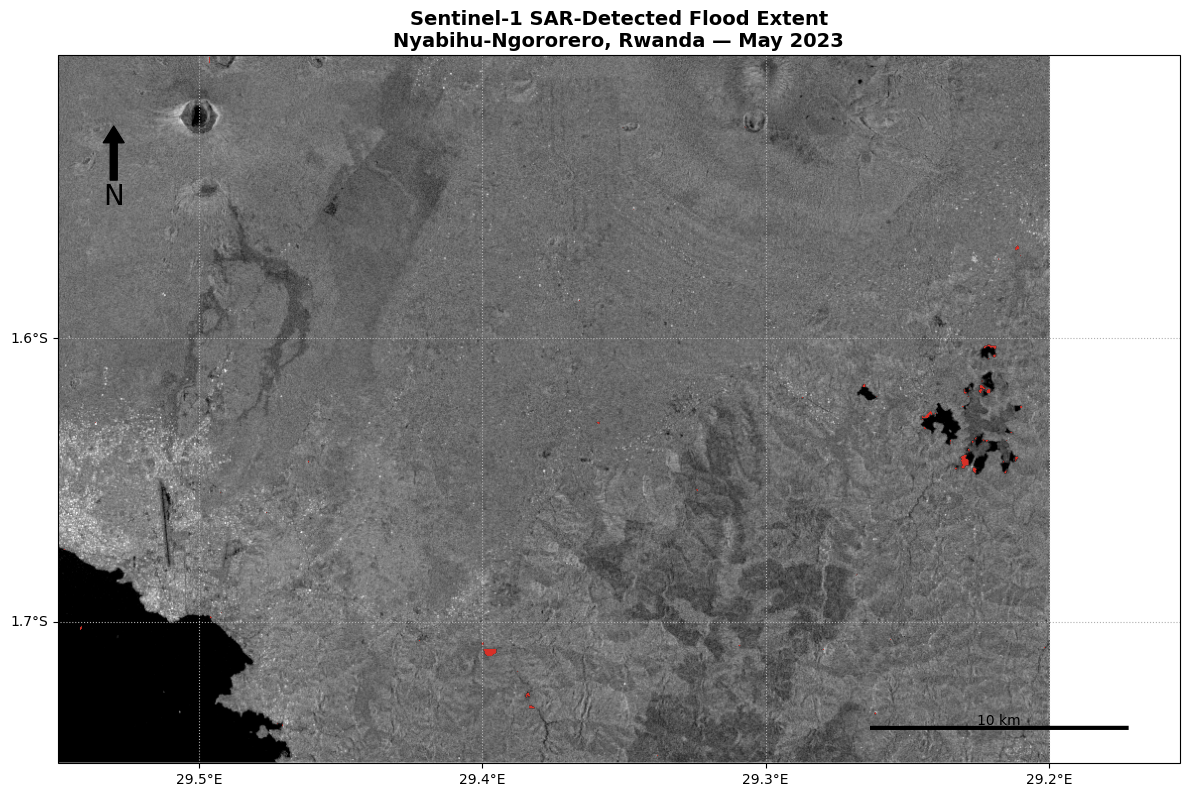

Map saved as flood_extent_map.png — download it from the Colab file panel on the left.


In [3]:
# ============================================
# STEP 3 — Rebuild your flood detection (same as your original script)
# ============================================

aoi = ee.Geometry.Rectangle([29.20, -1.75, 29.55, -1.50])  # Your AOI

s1 = ee.ImageCollection('COPERNICUS/S1_GRD') \
    .filterBounds(aoi) \
    .filter(ee.Filter.eq('instrumentMode', 'IW')) \
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VH')) \
    .select('VH')

before = s1.filterDate('2023-04-15', '2023-04-30').mean().clip(aoi)
after  = s1.filterDate('2023-05-03', '2023-05-10').mean().clip(aoi)

beforeFiltered = before.focal_mean(50, 'circle', 'meters')
afterFiltered  = after.focal_mean(50, 'circle', 'meters')

diff = afterFiltered.subtract(beforeFiltered)

flooded = diff.lt(-3).selfMask()  # Manual -3dB threshold, your primary result

# ============================================
# STEP 4 — Build the atlas-quality map with cartoee
# ============================================

fig = plt.figure(figsize=(12, 10))

# Visualization parameters — flood extent in a clear, bold color
vis_params = {'palette': ['#d73027']}  # Strong red for visibility

# Region as a flat bounding box [west, south, east, north] — matches your AOI directly
region = [29.20, -1.75, 29.55, -1.50]

ax = cartoee.get_map(flooded, region=region, vis_params=vis_params)

# Add a basemap underneath for context (satellite or terrain)
cartoee.add_layer(ax, before.visualize(min=-25, max=0, palette=['black', 'white']),
                   region=region)
cartoee.add_layer(ax, flooded, vis_params=vis_params, region=region)

# Gridlines (coordinate lat/long lines)
cartoee.add_gridlines(ax, interval=[0.1, 0.1], linestyle=':')

# North arrow
cartoee.add_north_arrow(ax, text='N', xy=(0.05, 0.9),
                          text_color='black', arrow_color='black', fontsize=20)

# Scale bar
cartoee.add_scale_bar_lite(ax, length=10, xy=(0.05, 0.05), fontsize=10,
                             color='black', unit='km')

# Title
ax.set_title('Sentinel-1 SAR-Detected Flood Extent\nNyabihu-Ngororero, Rwanda — May 2023',
              fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('flood_extent_map.png', dpi=300, bbox_inches='tight')
plt.show()

print("Map saved as flood_extent_map.png — download it from the Colab file panel on the left.")